# Tutorial 2: Image segmentation with random forest

Now we can explore a slightly more advanced approach to image segmentation using machine learning (ML)!

This tutorial assumes no prior AI/ML background. We explain each idea before coding it.

## What you will learn

1. What a random forest model is and how it segments images
2. How to build a train/validation/test split for segmentation
3. How handcrafted features can represent image texture and intensity
4. How to evaluate and visualize segmentation predictions from random forest

## Credits

These code chunks were initially developed by Sameera Nalin Venkat, which were refined by GitHub Co-pilot on VS Code.

## Points of contact

- Sameera Nalin Venkat (Post Doctorate RA C/William R. Wiley Postdoctoral Fellow): sameera.nalinvenkat@pnnl.gov
- Aramy Truong (Computational Scientist): aramy.truong@pnnl.gov

Before we get started, let us review the core ideas of random forest image segmentation and how it works!


## What is machine learning?

- Machine learning (ML) is a branch of artificial intelligence
- ML involves learning patterns from examples instead of following only fixed, hand-written rules

To summarize, in ML, we provide example inputs and expected output and the model learns how they are connected.

The random forest model learns from example images and masks 
- So it can predict whether each pixel belongs to the object of interest or the background

A few beginner-friendly terms:

- **Features**: Measurable properties of the image, such as pixel intensity, texture, or edge information
- **Labels/annotations/ground truth**: Correct answers provided to the model during training
- **Model**: Mthematical system that learns the relationship between features and labels
- **Prediction**: Output produced by the trained model for a new image

Here is a schematic of different stages in an ML model for image segmentation:

<div style="text-align: center; margin-top: 20px"><img src="notebook_img/ML_intuition.png" width="600" alt="Machine learning schematic"></div>

There are 3 important stages:

1. Training is done to teach the ML model patterns from the input image and ground truth labels (or annotations)
2. Validation is performed to tune the ML model for the best performance
3. Testing is for obtaining unbiased evaluation of the model

Once these 3 stages are optimized, inference is done on images that the model has never encountered before.

## Where is machine learning being used?

Machine learning is now used in many scientific and engineering workflows 
- Because it can identify patterns that are difficult to capture with simple thresholding or manual rules

Some common applications include:

- **Medical imaging**: detecting tumors, organs, or damaged tissue in scans
- **Remote sensing**: classifying land cover, water, vegetation, or urban regions from satellite images
- **Biology and microscopy**: segmenting cells, tissues, or microbial structures

In this tutorial, we use ML for image segmentation of XCT images of soil systems
- Such images often contain complex textures, uneven lighting, and overlapping intensity ranges
- These conditions can make simple threshold-based segmentation hard to generalize across a wide variety of XCT images

## Challenges in machine learning

Although ML is powerful, it also comes with some challenges:

1. **Data quality**: If the training masks are noisy or incorrect, the model will learn the wrong patterns
2. **Limited training data**: Too few examples can reduce model accuracy and robustness
3. **Overfitting**: ML model may memorize the training set instead of learning general patterns
4. **Underfitting**: ML model may be too simple to capture meaningful structure in the data

It is important to use training, validation, and test sets, and to evaluate the model carefully before trusting its predictions on new images.

## What is random forest?

Random forest is a supervised machine learning algorithm that combines many decision trees and lets them vote on the final prediction.

Here is how a random forest looks like: 

<div style="text-align: center; margin-top: 20px"><img src="notebook_img/random_forest_setup.png" width="600" alt="Machine learning schematic"></div>

A decision tree makes a sequence of if-then decisions, such as:

- Is pixel intensity greater than a threshold?
- Is local texture rough or smooth?
- Is the neighborhood pattern likely foreground or background?

A single tree can be sensitive to noise. Random forest improves stability by training many trees.

Because each tree sees slightly different data and features, the forest reduces overfitting and usually generalizes better than one tree.

For segmentation in this tutorial, each pixel is treated as one sample:

- Input to the model: handcrafted features for each pixel (intensity and texture at multiple scales)
- Output from the model: probability that the pixel belongs to foreground
- Final mask: created by applying a threshold to probabilities

## How do we evaluate the performance of the random forest (or any ML model)?

There are a number of evaluation metrics used. For this tutorial, we will use intersection over union (IoU).

### Intersection over Union (IoU)

IoU measures how well a predicted segmentation mask overlaps with the ground truth mask.

Given a predicted binary mask $\hat{M}$ and a ground truth binary mask $M$, IoU is defined as:

$$\text{IoU} = \frac{|\hat{M} \cap M|}{|\hat{M} \cup M|}$$

Where:

- $|\hat{M} \cap M|$ is the number of pixels that are foreground in **both** the prediction and the ground truth (intersection)
- $|\hat{M} \cup M|$ is the number of pixels that are foreground in **either** the prediction or the ground truth (union)

IoU ranges from 0 to 1:

- $\text{IoU} = 1$ means the prediction perfectly matches the ground truth
- $\text{IoU} = 0$ means there is no overlap at all between the prediction and the ground truth

IoU penalizes both false positives (pixels predicted as foreground but actually background) and false negatives (pixels missed by the model).

## Step 1 — Import libraries
The code cell above imports everything needed for the full workflow.

### Why these libraries?
- `numpy`: array operations
- `PIL`: image loading/resizing
- `skimage.feature`: handcrafted feature extraction
- `RandomForestClassifier`: supervised pixel classification
- `matplotlib`: prediction visualization

If this is your first run after opening the notebook, execute cells from top to bottom.

In [3]:
# ----------------------------
# Basic Imports
# ----------------------------

import os  # File and folder utilities
import numpy as np  # Numerical arrays and random operations
import matplotlib.pyplot as plt  # Visualization of predictions
from PIL import Image  # Reading and resizing .tif/.tiff images
from skimage import feature  # Feature extraction (multiscale texture/intensity)
from sklearn.ensemble import RandomForestClassifier  # Classical ML classifier for segmentation

## Step 2 — Configure paths and hyperparameters
The previous code cell defines all settings in one place so beginners can tweak values safely.

### Parameters you can experiment with
- `IMG_SIZE`: larger sizes keep detail but increase runtime/memory
- `PIXELS_PER_IMAGE`: more sampled pixels usually improve stability
- `sigma_min/sigma_max`: controls feature scales
- split fractions: control train/val/test size

Tip: change only one setting at a time and compare IoU.

In [7]:
# ----------------------------
# Configuration
# ----------------------------
# Folder containing RGB input images (.tif/.tiff)
IMAGE_DIR = "./data/raw_img/"
# Folder containing binary ground-truth masks (from Otsu thresholding, in this case) (.tif/.tiff)
MASK_DIR  = "./data/otsu_masks/"

# Every image/mask will be resized to this shape before processing
# PIL expects (width, height)
IMG_SIZE  = (256, 256)

# To keep training fast, we randomly sample this many pixels per training image (using all pixels can be very large for big datasets)
PIXELS_PER_IMAGE = 1500

# Feature scales for multiscale features: smaller captures local detail, larger captures broader texture patterns
sigma_min, sigma_max = 1, 16

# Data split ratios by image (NOT by pixel)
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

# Fixed seed for reproducibility (same split + sampling every run)
RANDOM_SEED = 0

# We tune the final binary decision threshold on the validation set
# The model outputs probabilities; threshold converts probability -> 0/1 mask
THRESHOLDS = np.linspace(0.2, 0.8, 13)

# Number of test examples to visualize
NUM_PREVIEW_TEST = 3

# Folder where predicted TEST masks will be saved as .png files (feel free to change this)
OUT_DIR = "./output/rf_test_results"

## Step 3 — Define helper functions
These helper functions keep the rest of the notebook easy to read.

### Key idea
`predict_proba_fg(...)` returns a **probability map** for foreground, not a hard mask. Later we choose a threshold to turn that map into binary predictions.

In [5]:
# ----------------------------
# Helper Functions
# ----------------------------
def load_img(path):
    """Load an RGB image and resize it to IMG_SIZE"""
    return np.array(Image.open(path).convert("RGB").resize(IMG_SIZE))

def load_mask(path):
    """Load a grayscale mask and resize with nearest-neighbor interpolation

    Nearest-neighbor is important for masks so we do not create intermediate
    label values during resizing
    """
    return np.array(Image.open(path).convert("L").resize(IMG_SIZE, Image.NEAREST))

def compute_iou(pred_bin, gt_bin):
    """Compute Intersection over Union (IoU) for binary masks

    IoU = intersection / union
    If both masks are empty, we define IoU as 1.0
    """
    pred = pred_bin.astype(bool)
    gt   = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return 1.0 if union == 0 else inter / union

def predict_proba_fg(img_rgb, clf):
    """Return per-pixel foreground probability using trained classifier."""
    # Compute handcrafted multiscale features per pixel
    feats = feature.multiscale_basic_features(
        img_rgb,
        intensity=True,
        edges=False,
        texture=True,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
        channel_axis=-1,
    )
    # Flatten HxWxF -> (H*W)xF for scikit-learn
    X = feats.reshape(-1, feats.shape[-1])
    # Keep probability for class 1 (foreground), then reshape back to image grid
    proba = clf.predict_proba(X)[:, 1].reshape(img_rgb.shape[:2])
    return proba

## Step 4 — Build data splits
This stage discovers files and creates train/validation/test image indices.

### Why split by image instead of pixel?
Pixels from the same image are highly correlated. If train and test include pixels from the same image, test performance can look unrealistically good.

In [8]:
# ----------------------------
# Gather File Names
# ----------------------------
# Sort files so image/mask pairing is deterministic by filename order
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith((".tif", ".tiff"))])
mask_files  = sorted([f for f in os.listdir(MASK_DIR)  if f.lower().endswith((".tif", ".tiff"))])

# Basic safety check: same number of images and masks, and not empty
assert len(image_files) == len(mask_files) and len(image_files) > 0, "Image/mask count mismatch or empty folders."

N = len(image_files)
print(f"Found {N} image/mask pairs.")

# ----------------------------
# Split data by image index
# ----------------------------
# We split by image (not by pixel) to avoid leakage between train/test
rng = np.random.default_rng(RANDOM_SEED)
idx = np.arange(N)
rng.shuffle(idx)

n_train = int(round(TRAIN_FRAC * N))
n_val   = int(round(VAL_FRAC   * N))
n_test  = N - n_train - n_val

train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

print(f"Split: train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}")

Found 500 image/mask pairs.
Split: train=350, val=75, test=75


## Step 5 — Build sampled training pixels
Instead of using every pixel from every training image, we sample a manageable subset.

### Why sample pixels?
- Reduces runtime and memory use
- Keeps training practical on laptops
- Still captures diverse examples across images

A rough foreground/background balance is enforced to help the classifier learn both classes.

In [9]:
# ----------------------------
# Build Training Data (Pixel Sampling from TRAIN Images Only)
# ----------------------------
X_list, y_list = [], []

for k in train_idx:
    im_f = image_files[k]
    m_f  = mask_files[k]

    # Load one training image and its binary mask
    img  = load_img(os.path.join(IMAGE_DIR, im_f))
    mask = load_mask(os.path.join(MASK_DIR,  m_f))
    y = (mask > 0).astype(np.uint8)  # Convert to {0,1}

    # Extract per-pixel multiscale features from the image
    feats = feature.multiscale_basic_features(
        img,
        intensity=True,
        edges=False,
        texture=True,
        sigma_min=sigma_min,
        sigma_max=sigma_max,
        channel_axis=-1,
    )
    X = feats.reshape(-1, feats.shape[-1])  # (H*W, F)
    y = y.reshape(-1)                       # (H*W,)

    # Create a roughly balanced subset of foreground/background pixels
    fg = np.flatnonzero(y == 1)
    bg = np.flatnonzero(y == 0)

    n = PIXELS_PER_IMAGE
    n_fg = min(len(fg), n // 2)
    n_bg = min(len(bg), n - n_fg)

    # If one class is scarce, fill remaining slots from the other class
    if n_fg + n_bg < n:
        if len(fg) - n_fg > len(bg) - n_bg:
            n_fg = min(len(fg), n - n_bg)
        else:
            n_bg = min(len(bg), n - n_fg)

    sel = np.concatenate([
        rng.choice(fg, size=n_fg, replace=False) if n_fg else np.array([], dtype=int),
        rng.choice(bg, size=n_bg, replace=False) if n_bg else np.array([], dtype=int),
    ])
    rng.shuffle(sel)

    # Keep sampled pixels only (reduces memory and training time)
    X_list.append(X[sel])
    y_list.append(y[sel])

# Combine data from all training images into one matrix/label vector
X_train = np.vstack(X_list)
y_train = np.concatenate(y_list)
print("Training X:", X_train.shape, "fg fraction:", float(y_train.mean()))

Training X: (525000, 45) fg fraction: 0.5


## Step 6 — Train the Random Forest
The model learns rules from the sampled feature vectors and binary labels.

### Beginner note
Random Forest often works well out-of-the-box for structured features and is a strong baseline before moving to deep learning models.

In [10]:
# ----------------------------
# Train Random Forest Classifier
# ----------------------------
# RandomForest learns decision rules that map pixel features -> class label
clf = RandomForestClassifier(
    n_estimators=300,              # Number of trees
    n_jobs=-1,                     # Use all available CPU cores
    max_depth=15,                  # Limit tree depth to reduce overfitting
    class_weight="balanced_subsample",  # Helps when classes are imbalanced
    random_state=RANDOM_SEED,
 )

# Fit model on sampled training pixels
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Step 7 — Tune the probability threshold on validation data
The classifier predicts probabilities, but segmentation needs binary masks.

We test many thresholds and keep the one with the best mean validation IoU.

### Why not tune on test?
Using the test set for tuning leaks information and gives overly optimistic results.

In [11]:
# ----------------------------
# Tune threshold on VALIDATION set using mean IoU
# ----------------------------
# Model outputs probabilities in [0,1]. We need a threshold to make binary masks
best_t = None
best_iou = -1.0

for t in THRESHOLDS:
    ious = []
    for k in val_idx:
        img = load_img(os.path.join(IMAGE_DIR, image_files[k]))
        gt  = (load_mask(os.path.join(MASK_DIR, mask_files[k])) > 0).astype(np.uint8)

        proba = predict_proba_fg(img, clf)
        pred  = (proba >= t).astype(np.uint8)

        ious.append(compute_iou(pred, gt))

    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    if mean_iou > best_iou:
        best_iou = mean_iou
        best_t = float(t)

print(f"Best threshold on val: {best_t:.3f}  (mean IoU={best_iou:.4f})")

Best threshold on val: 0.450  (mean IoU=0.8910)


## Step 8 — Final evaluation on the test set
Now we evaluate once on unseen test images using the selected threshold.

Reported values:
- **mean IoU**: average segmentation quality
- **std IoU**: consistency across test images

In [12]:
# ----------------------------
# Evaluate on TEST set (mean IoU)
# ----------------------------
# Important: test set is used only once here for final reporting
test_ious = []
for k in test_idx:
    img = load_img(os.path.join(IMAGE_DIR, image_files[k]))
    gt  = (load_mask(os.path.join(MASK_DIR, mask_files[k])) > 0).astype(np.uint8)

    proba = predict_proba_fg(img, clf)
    pred  = (proba >= best_t).astype(np.uint8)

    test_ious.append(compute_iou(pred, gt))

test_mean_iou = float(np.mean(test_ious)) if len(test_ious) else float("nan")
test_std_iou  = float(np.std(test_ious))  if len(test_ious) else float("nan")
print(f"TEST mean IoU: {test_mean_iou:.4f}  (std={test_std_iou:.4f}, n={len(test_ious)})")

TEST mean IoU: 0.8933  (std=0.0409, n=75)


## Step 9 — Visualize predictions

This comparison view (image / ground truth / prediction) helps explain model behavior.

These questions may be helpful to explore for your understanding:

- Where does the model over-segment?
- Where does it miss foreground?
- Do errors correlate with low contrast or texture?

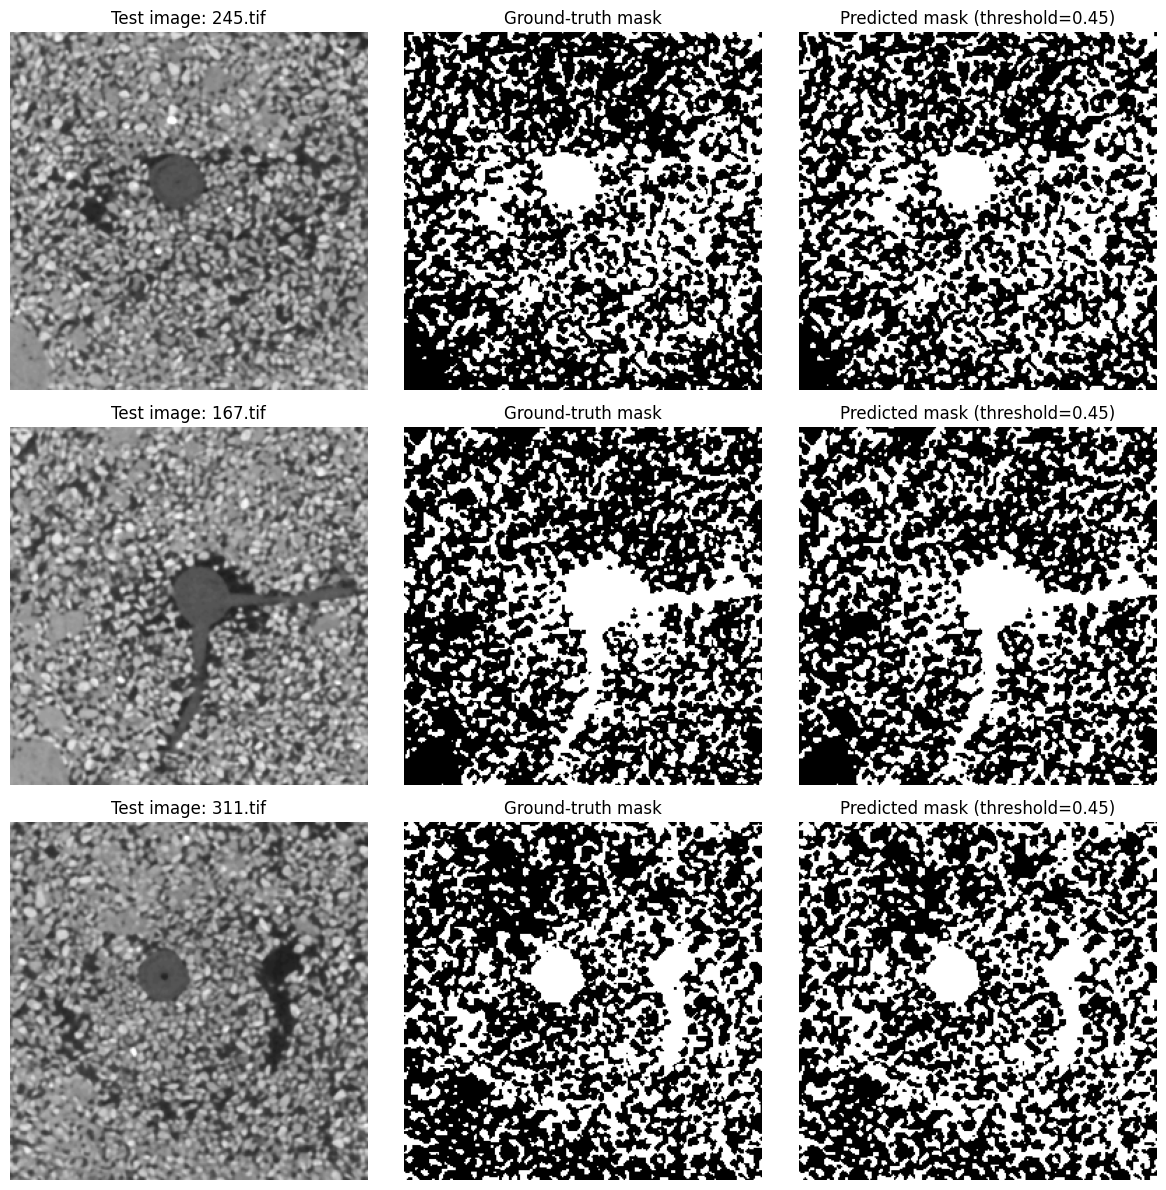

In [13]:
# ----------------------------
# Preview a few TEST predictions (optional)
# ----------------------------
# Visual inspection helps you catch failure modes that a single metric might miss
num_show = min(NUM_PREVIEW_TEST, len(test_idx))
if num_show > 0:
    fig, axes = plt.subplots(num_show, 3, figsize=(12, 4 * num_show))
    if num_show == 1:
        axes = np.expand_dims(axes, 0)

    for i in range(num_show):
        k = test_idx[i]
        img = load_img(os.path.join(IMAGE_DIR, image_files[k]))
        gt  = (load_mask(os.path.join(MASK_DIR, mask_files[k])) > 0).astype(np.uint8)

        proba = predict_proba_fg(img, clf)
        pred  = (proba >= best_t).astype(np.uint8)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Test image: {image_files[k]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[i, 1].set_title("Ground-truth mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[i, 2].set_title(f"Predicted mask (threshold={best_t:.2f})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

## Step 10 — Save predicted masks

The last cell writes binary prediction masks for test images to disk.

These files can be used for:

- Qualitative review
- Downstream analysis
- Side-by-side comparison with other segmentation methods

## Suggested exercises 

1. Increase `PIXELS_PER_IMAGE` and observe runtime vs IoU.
2. Try a wider threshold grid.
3. Turn on `edges=True` in feature extraction and compare performance.
4. Compare this baseline with a U-Net model.

In [14]:
# ----------------------------
# Save predictions for TEST set
# ----------------------------
# We save each predicted mask using the original image base name
os.makedirs(OUT_DIR, exist_ok=True)

for k in test_idx:
    im_f = image_files[k]

    img = load_img(os.path.join(IMAGE_DIR, im_f))
    proba = predict_proba_fg(img, clf)
    pred  = (proba >= best_t).astype(np.uint8)

    base, _ = os.path.splitext(im_f)
    out_path = os.path.join(OUT_DIR, base + ".png")
    Image.fromarray((pred * 255).astype(np.uint8)).save(out_path)

print("Saved TEST predictions to:", OUT_DIR)

Saved TEST predictions to: ./output/rf_test_results


## Helpful Resources

If you would like to explore random forest in greater detail, check out the following resources to learn more:

- Another simple tutorial for random forest: https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_trainable_segmentation.html
- StatQuest on random forest: https://www.youtube.com/watch?v=J4Wdy0Wc_xQ 
- Random forest overview (Python for Microscopists): https://www.youtube.com/watch?v=OUCwt8loM6s

Happy learning!